# Dataset Name:Most Streamed Spotify Songs 2023 

###### Dataset Link: https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023/data

##### The dataset used in this project is the “Top Spotify Songs 2023”, which contains a comprehensive collection of the most popular songs on Spotify in 2023. It includes detailed information about each track such as track name, artist(s), release date, and popularity metrics across multiple music platforms including Spotify, Apple Music, Deezer, and Shazam. In addition to platform presence and streaming statistics, the dataset also contains various audio features such as danceability, energy, valence, tempo, and acousticness, which describe the musical characteristics of each song.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load with correct encoding
df = pd.read_csv("../data/raw/spotify-2023.csv", encoding="latin1")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [6]:
# Looking for the inconsistent indexes
print(df.columns)

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='str')


In [7]:
# Clearing duplicates
df = df.drop_duplicates()
df = df.dropna()
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [8]:
# Convert to numeric
for col in ['danceability_%', 'energy_%', 'streams']:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
# Drop NaN only for existing columns
cols_to_use = [c for c in ['danceability_%', 'energy_%', 'streams'] if c]
df = df.dropna(subset=cols_to_use)


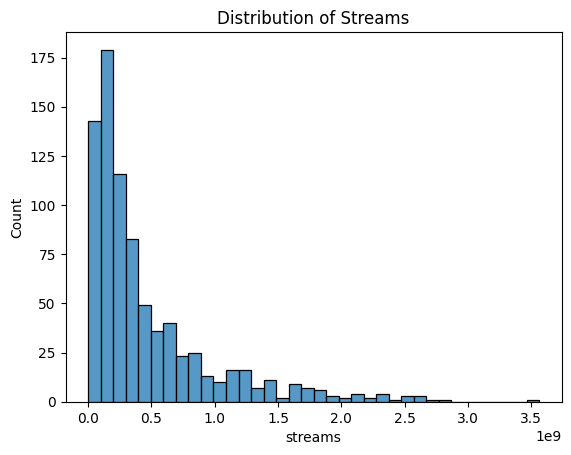

In [10]:
# Visualization 1
sns.histplot(df['streams'])
plt.title("Distribution of Streams")
plt.savefig("../reports/Distribution_of_Streams.png", dpi=300, bbox_inches='tight')
plt.show()

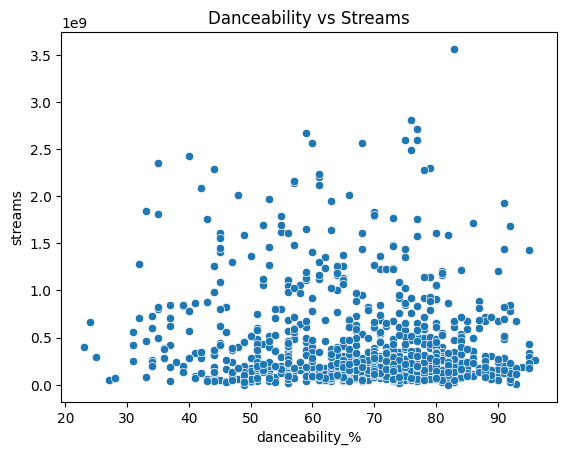

In [11]:
# Visualization 2
if 'danceability_%' and 'streams':
    sns.scatterplot(x='danceability_%', y='streams', data=df)
    plt.title("Danceability vs Streams")
    plt.savefig("../reports/Danceability_vs_Streams.png", dpi=300, bbox_inches='tight')
    plt.show()


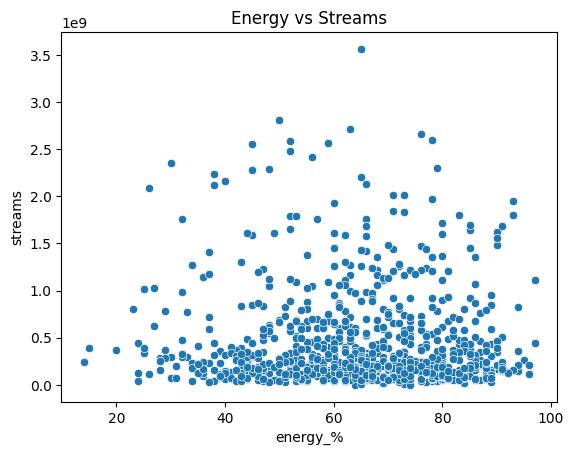

In [12]:
# Visualization 3
if 'energy_%' and 'streams':
    sns.scatterplot(x='energy_%', y='streams', data=df)
    plt.title("Energy vs Streams")
    plt.savefig("../reports/Energy_vs_Streams.png", dpi=300, bbox_inches='tight')
    plt.show()


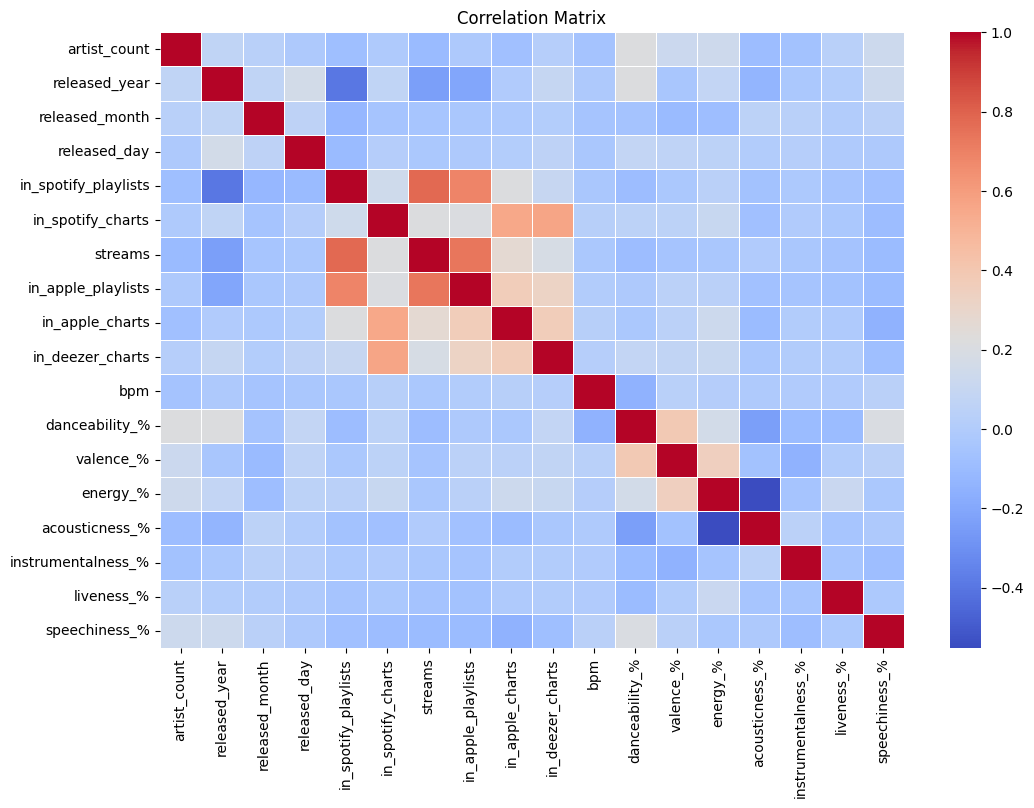

In [13]:
# Visualization 4
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False,   # REMOVE numbers
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.savefig("../reports/Correlation Matrix.png", dpi=300, bbox_inches='tight')
plt.show()

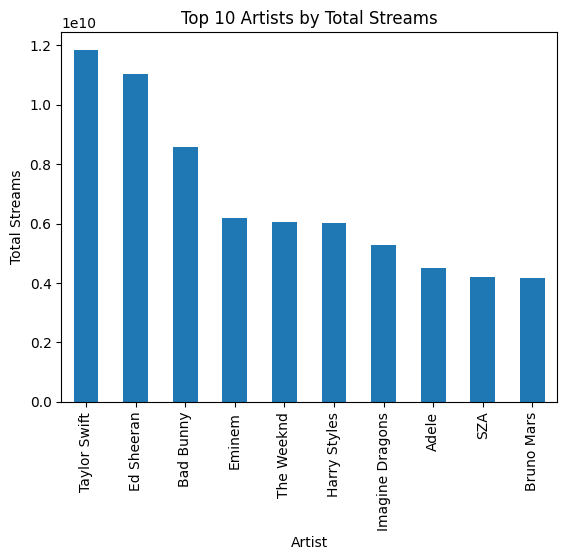

In [17]:
top_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(10)

top_artists.plot(kind='bar')
plt.title("Top 10 Artists by Total Streams")
plt.xlabel("Artist")
plt.ylabel("Total Streams")

plt.savefig("../reports/Top_Artists.png", dpi=300, bbox_inches='tight')
plt.show()

**Question:** Which artists have the highest total number of streams?

This bar chart displays the top 10 artists based on total streams. It helps identify dominant contributors in the dataset and highlights whether popularity is concentrated among a few artists or more evenly distributed.

Understanding this distribution provides context for the dataset and may explain patterns observed in other variables, such as why some songs achieve significantly higher stream counts.


In [ ]:
# Save cleaned data
df.to_csv("../data/cleaned.csv", index=False)

### T1, we performed exploratory data analysis on the Spotify 2023 dataset. We examined the distribution of streams and the relationships between key audio features such as danceability and energy. The visualizations showed that songs with higher danceability and energy generally tend to have more streams, suggesting that more upbeat and rhythm-driven tracks are often more popular. The correlation heatmap confirmed moderate positive relationships between these audio features and streaming counts, although the relationships were not extremely strong.

### We also identified and cleaned the dataset by removing duplicates, handling missing values, and converting important columns into numeric format to ensure accurate analysis. Scatter plots helped us observe general trends between features and popularity, while also revealing that the data contains a large amount of variation rather than strict patterns.

### One surprising observation was that the relationship between audio features and streams is not consistent for all songs, meaning that some tracks with lower energy or danceability still achieve high popularity.

### This suggests that while audio characteristics play an important role, they are not the only factor influencing a song’s success, and other external variables may also be important to consider in further analysis.